<a href="https://colab.research.google.com/github/mobius29er/AIML_Class/blob/main/colab_activity_21_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Colab Activity 21.3: Using Keras

**Expected Time = 60 minutes**



This activity focuses on using the `keras` library to build an Artificial Neural Network using the the Titanic dataset.  You will now use all the rows of the data and the `age` and `fare` columns to build a basic network.  After building the model you will visualize the loss for each epoch.

#### Index

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)
- [Problem 3](#-Problem-3)
- [Problem 4](#-Problem-4)
- [Problem 5](#-Problem-5)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import plot_model

import warnings
warnings.filterwarnings('ignore')

In [2]:
titanic = sns.load_dataset('titanic').dropna(subset = ['age'])
X = titanic[['age', 'fare']].values
y = titanic['survived'].values
print(X.shape)

(714, 2)


[Back to top](#-Index)

### Problem 1

#### A Basic Network



To begin, use `keras` and the `Sequential` model to create a model with the following architecture:

- One hidden layer with one node
- One output node
- Use the sigmoid activation function on all nodes

Assign this model to the variable `single_node_model`.

In [4]:
tf.random.set_seed(42)
single_node_model = Sequential([
    Dense(1, activation='sigmoid', input_shape=(X.shape[1],)),
    Dense(1, activation='sigmoid')
])



### ANSWER CHECK
single_node_model

<Sequential name=sequential, built=True>

In [ ]:
single_node_model.layers[0].activation

<function keras.activations.sigmoid(x)>

[Back to top](#-Index)

### Problem 2

#### Compiling the Network



Now, compile the `single_node_model` model defined above using the settings below:

- `optimizer = rmsprop`
- `loss = binary_crossentropy`
- `metrics = ['accuracy']`

In [5]:
tf.random.set_seed(42)
single_node_model.compile(optimizer='rmsprop',
                          loss='binary_crossentropy',
                          metrics=['accuracy'])




### ANSWER CHECK
single_node_model

<Sequential name=sequential, built=True>

[Back to top](#-Index)

### Problem 3

#### Fit the model



Next, fit the `single_node_model` model below to the data `X` and `y` using the following parameters:

- `epochs = 20`
- `batch_size = 10`
- `verbose = 0`

Ensure to use `tf.random.set_seed(42)` to assure proper grading.  

Assign your fit model to the variable `history` below.

In [6]:
tf.random.set_seed(42)
history = single_node_model.fit(X, y, epochs=20, batch_size=10, verbose=0)


### ANSWER CHECK
history.params

{'verbose': 0, 'epochs': 20, 'steps': 72}

[Back to top](#-Index)

### Problem 4

#### Evaluate the model



Use the `.evaluate` method on your `single_node_model` with the `X` and `y` arrays to examine the loss and accuracy of the model.  Assign these values to the variables `single_loss` and `single_acc` below.

In [7]:
single_loss, single_acc = single_node_model.evaluate(X, y, verbose=0)


### ANSWER CHECK
print(single_loss)
print(single_acc)

0.6754553914070129
0.593837559223175


[Back to top](#-Index)

### Problem 5

#### A More Complex Model



To try to improve the model, now build and evaluate a second model that uses a single hidden layer with 100 nodes, and a single output layer.  

For the hidden layer use the `relu` activation function and for the output layer use the `sigmoid` activation.  

Again, set the `np.random.seed(42)`, using the same compile settings and train settings for number of epochs and batch size.  Assign the accuracy of the model to `hundred_acc` below.

In [8]:
tf.random.set_seed(42)
complex_model = Sequential([
    Dense(100, activation='relu', input_shape=(X.shape[1],)),
    Dense(1, activation='sigmoid')
])

complex_model.compile(optimizer='rmsprop',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

complex_model.fit(X, y, epochs=20, batch_size=10, verbose=0)

single_loss, hundred_acc = complex_model.evaluate(X, y, verbose=0)


### ANSWER CHECK
print(hundred_acc)

0.6848739385604858


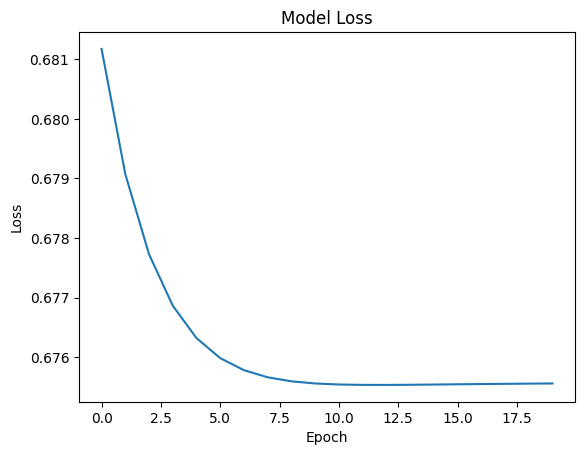

In [9]:
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()